# Latent Dirichlet Allocation

## Exploring Changing Sentiment in Climate Articles: 2013 to 2023

#### This notebook explores LDA concepts within the corpus.

#### Written by Rafael Alvarado(1) and Caroline Kranefuss(1).

(1) University of Virginia, 2026

### Imports

In [20]:
# General imports
import pandas as pd 
import numpy as np 
import os
import sys

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
sns.set_theme(style='white')
pio.renderers.default = 'iframe'

# Project-specific imports
import glob
from glob import glob
import nltk
nltk_resources = [
    'tokenizers/punkt', 
    'averaged_perceptron_tagger_eng',
    'corpora/stopwords', 
    'help/tagsets'
]

for resource in nltk_resources:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource)

# Scikit Learn
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA, TruncatedSVD as SVD
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA, NMF # Note importing of two topic modelers
        
# ----File Stitching----
# If not in repo home folder, cd back 
if os.path.basename(os.getcwd()) != "evolving_sentiment_climate":
    os.chdir('..')
# If a file is in /sources/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), 'sources'))
source_dir = "sources"
source_files_paths = glob(f"{source_dir}/*.xml")
# Same for csvs
sys.path.append(os.path.join(os.getcwd(), 'csvs'))
csvs_dir = "csvs"
csvs_files_paths = glob(f"{csvs_dir}/*.csv")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


### Setting OHCO

In [15]:
# Define OHCO
OHCO = ['year', 'mth_day', 'doc_id', 'sent_num', 'token_num']
bags = dict(
    SENTS = OHCO[:4],
    DOCS = OHCO[:3],
    MTH_DAY = OHCO[:2],
    YEAR = OHCO[:1]
)

bag = DOCS

### Prepping Data

In [6]:
TOKENS = pd.read_csv('csvs/CORPUS/CORPUS.csv').set_index(OHCO)
TOKENS.head()

pos pos_group token_str  term_str
year mth_day doc_id sent_num token_num                                   
2018 12-18   0      0        0           DT        DT       The       the
                             1           JJ        JJ  southern  southern
                             2           NN        NN      cone      cone
                             3           IN        IN        of        of
                             4          NNP        NN     South     south

In [19]:
# Creating a DOCS table, filtering for nouns!
# Group by bag(doc_id), join strings, convert to df and format
DOCS = TOKENS[TOKENS.pos.str.match(r'.+')]\
    .groupby('doc_id').term_str\
    .apply(lambda x: ' '.join(map(str,x)))\
    .to_frame()\
    .rename(columns={'term_str':'doc_str'})

DOCS.head()

,doc_str
doc_id,
0,the southern cone of south america has been th...
1,anthropogenic ocean warming threatens the surv...
2,environmental changes eg global warming climat...
3,neither reducing the use of antibiotics nor di...
4,by 2050 the global human population will have ...


### Creating Vector Space

In [23]:
# Use english stopwords
my_stop_words = list(text.ENGLISH_STOP_WORDS)

# Built engine and model, build DFs!!
count_engine = CountVectorizer(max_df=.9, min_df=10, stop_words=my_stop_words)
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()
VOCAB = pd.DataFrame(index=TERMS)
VOCAB.index.name = 'term_str'
DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)
DTM

,0001,001,002,004,005,007,01,02,025,03,...,years,yellow,yield,yielded,young,zero,zone,zones,µl,µm
doc_id,,,,,,,,,,,,,,,,,,,,,
0,0,1,0,0,0,0,0,0,0,1,...,4,0,0,0,0,0,1,0,0,0
1,6,0,0,0,22,0,1,0,0,0,...,2,0,0,0,0,0,0,0,0,0
2,0,0,0,0,2,0,0,0,0,0,...,2,1,1,0,0,0,0,0,0,0
3,2,2,0,0,7,3,4,2,2,0,...,0,0,0,0,0,0,0,0,2,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,17,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,6,0,1,0,0,1,0,0,0,0,...,6,0,0,0,1,1,15,35,0,0
88,5,0,1,0,6,0,0,1,0,0,...,8,0,1,0,0,1,0,6,0,0
89,2,0,0,0,0,1,1,0,0,0,...,22,0,0,0,1,2,0,0,0,0


In [26]:
#settings 
n_topics = 20
max_iter = 100
n_top_terms = 9

TNAMES = [f"T{str(x).zfill(len(str(n_topics)))}" for x in range(n_topics)]

# Generate model
topic_engine = LDA(n_components=n_topics, max_iter=max_iter)

topic_model = topic_engine.fit_transform(count_model)

### Create THETA

In [28]:
THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'
THETA.sample(10).T.style.background_gradient(axis=None) # Use default color map


doc_id,50,37,6,75,56,89,18,80,49,66
topic_id,,,,,,,,,,
T00,0.000016,0.000039,0.000040,0.000027,0.070900,0.000019,0.000035,0.066742,0.000042,0.000041
T01,0.000016,0.000039,0.000040,0.000027,0.183131,0.000019,0.000035,0.000020,0.024446,0.000041
T02,0.000016,0.000039,0.054397,0.000027,0.190147,0.000019,0.000035,0.000020,0.069594,0.000041
T03,0.000016,0.117853,0.000040,0.000027,0.000025,0.999634,0.000035,0.000020,0.077085,0.000041
T04,0.000016,0.018944,0.437041,0.000027,0.393174,0.000019,0.000035,0.000020,0.124766,0.083844
T05,0.000016,0.041096,0.000040,0.000027,0.000025,0.000019,0.209247,0.000020,0.015675,0.526505
T06,0.000016,0.000039,0.000040,0.921122,0.000025,0.000019,0.399212,0.000020,0.000042,0.340870
T07,0.000016,0.000039,0.000040,0.000027,0.035070,0.000019,0.000035,0.599620,0.000042,0.000041
T08,0.000016,0.043906,0.000040,0.000027,0.000025,0.000019,0.000035,0.000020,0.000042,0.000041


### Creating PHI

(Sort of a topic model)

In [29]:
PHI = pd.DataFrame(topic_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'
PHI.T.sample(10).T.style.background_gradient(axis=None)

term_str,growth,densities,quantifying,authors,relative,release,length,coupled,plots,demand
topic_id,,,,,,,,,,
T00,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T01,5.235816,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T02,24.586347,0.050000,0.050000,20.703823,0.050000,0.050000,0.050000,0.050000,0.050000,6.610780
T03,19.847514,0.050000,3.047229,10.982766,2.910516,1.140186,8.732397,0.050000,1.161165,0.050000
T04,8.719164,9.570727,4.546545,0.050000,23.981908,10.293837,0.050000,2.502176,0.050000,5.313874
T05,106.244239,0.050000,0.050000,0.050000,15.606422,33.757631,8.830109,3.873734,8.485117,2.596253
T06,4.655264,45.107462,1.970760,0.050000,32.424494,1.882640,21.909787,0.050000,0.050000,2.414409
T07,116.224152,0.050000,0.050000,0.050000,16.638475,1.851627,29.492151,0.050000,6.439696,3.782131
T08,5.651455,6.388763,1.639476,0.050000,10.569676,2.960595,0.050000,0.050000,68.181534,0.050000


### Creating TOPICS, Obtaining Top Terms, Sorting

In [32]:
# Stacking PHi, grouping by topic id and joining, only keeping the number of top terms chosen
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')
TOPICS

,top_terms
topic_id,
T00,soil water soils content cm samples organic ra...
T01,fish prediction air quality protein disease re...
T02,city model cities public approaches urban proj...
T03,populations population dna age number sample d...
T04,model areas models area precipitation temperat...
T05,temperature rates coral effects treatment larv...
T06,coral density group individuals species corals...
T07,plant plants stress water growth bacteria show...
T08,control vegetation coastal south species time ...


In [33]:
# Sort by Doc Weight using the sum to calculate

TOPICS['doc_weight_sum'] = THETA.sum()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
TOPICS.sort_values('doc_weight_sum', ascending=False).style.background_gradient(cmap='YlGnBu', axis=0)

C:\Users\student\AppData\Local\Temp\ipykernel_36180\3765302116.py:4: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
C:\Users\student\AppData\Local\Temp\ipykernel_36180\3765302116.py:4: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()


,top_terms,doc_weight_sum,term_freq
topic_id,,,
T11,populations species population genetic habitat range distribution predicted suitable,10.161302,0.094148
T04,model areas models area precipitation temperature potential values variables,9.518324,0.094581
T05,temperature rates coral effects treatment larvae conditions microbial heat,8.839725,0.096483
T17,species diversity samples sequences community phylogenetic taxa communities sample,7.563278,0.090563
T16,species sites mm site native time biodiversity specimens number,7.529606,0.074108
T12,species forest tree sites class trees station forests classes,6.667444,0.066753
T06,coral density group individuals species corals effect reefs size,6.328994,0.058032
T07,plant plants stress water growth bacteria showed leaf area,6.006976,0.053422
T18,size species plant habitat plants area fungi areas habitats,4.840903,0.052186


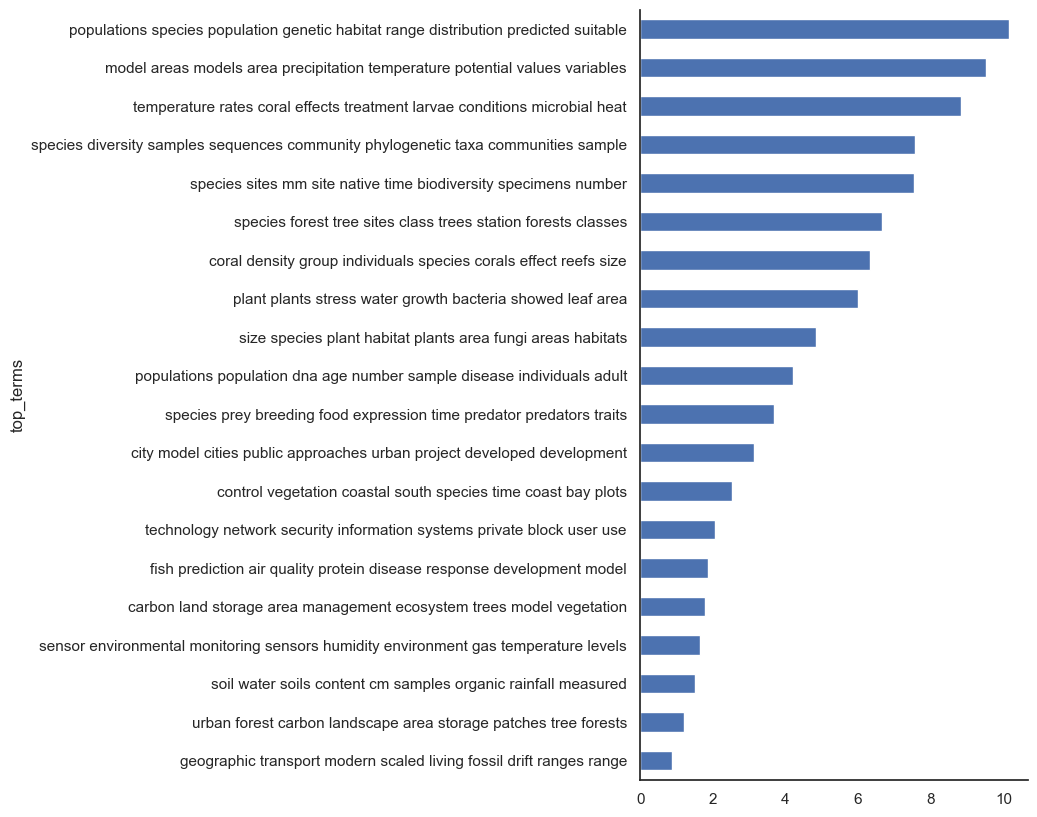

In [35]:
# Again, sort values and plot it for another visualization
TOPICS.sort_values('doc_weight_sum', ascending=True).plot.barh(y='doc_weight_sum', x='top_terms', figsize=(5, n_topics/2), legend=False)
sns.despine()
plt.show()

### Exploring by Year